## Hypothesis 3: Action-oriented search queries (e.g., “delete Facebook”) returned to pre-event levels faster than information-oriented search queries.

In [2]:
#imports

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [22]:
def loadcsv (path, col_name):
    df = pd.read_csv (path, skiprows = 1, names = ["date", col_name], index_col= "date")

    df[col_name]= pd.to_numeric (df[col_name], errors = "coerce")
    df.index = pd.to_datetime (df.index,errors = "coerce" )

    df = df.dropna().sort_index()
    return df

def add_csv_to_df(path, col_name, old_df):
    
    new_df = pd.read_csv(path, skiprows=1, names = ["date", col_name], index_col="date")
    new_df[col_name]= pd.to_numeric(new_df[col_name], errors = "coerce")
    new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
    new_df = new_df.dropna().sort_index()

    merged_df = pd.concat([old_df, new_df], axis = 1, join = "outer")
    return merged_df

### Action-oriented search queries:

how_to_delete_Facebook

how_to_delete_Facebook_account

delete_Facebook

Facebook_privacy_settings

### Information-oriented search queries:

cambridge analytica

cambridge analytica data scandal

facebook cambridge analytica

facebook data scandal

In [23]:
paths_action = [
    "../Data retrieval/new files/action to scandal/Facebook_privacy_settings.csv",
    "../Data retrieval/new files/action to scandal/delete_Facebook_account.csv",
    "../Data retrieval/new files/action to scandal/delete_Facebook.csv ",
    "../Data retrieval/new files/action to scandal/how_to_delete_Facebook.csv"
    ]

paths_information = [
    "../Data retrieval/new files/related to Cambridge Analytica/CA.csv",
    "../Data retrieval/new files/related to Cambridge Analytica/CA_scandal.csv",
    "../Data retrieval/new files/related to Facebook/FB_CA.csv",
    "../Data retrieval/new files/related to Facebook/FB_data_scandal.csv"
]

In [24]:
action_df = pd.DataFrame()
col_names = ["Facebook_privacy_settings", "delete_Facebook_account", "delete_Facebook", "how_to_delete_Facebook"]

for i, path in enumerate(paths_action):
    action_df = add_csv_to_df(path, col_names[i], action_df)
action_df = action_df.fillna(0)

action_df["interest"] = action_df.mean(axis = 1)
action_df


C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\2695096755.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\2695096755.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\2695096755.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\269

,Facebook_privacy_settings,delete_Facebook_account,delete_Facebook,how_to_delete_Facebook,interest
date,,,,,
2018-02-16,15.0,44.0,37.0,42.0,34.50
2018-02-17,0.0,52.0,43.0,49.0,36.00
2018-02-18,20.0,56.0,42.0,50.0,42.00
2018-02-19,20.0,45.0,40.0,44.0,37.25
2018-02-20,27.0,45.0,37.0,42.0,37.75
...,...,...,...,...,...
2018-10-08,16.0,47.0,45.0,55.0,40.75
2018-10-09,16.0,44.0,36.0,41.0,34.25
2018-10-10,16.0,39.0,33.0,40.0,32.00


In [25]:
information_df = pd.DataFrame()
col_names = ["cambridge_analytica", "cambridge_analytica_scandal", "facebook_cambridge_analytica", "facebook_data_scandal"]
for i, path in enumerate(paths_information):
    information_df = add_csv_to_df(path, col_names[i], information_df)
information_df = information_df.fillna(0)

information_df["interest"] = information_df.mean(axis = 1)
information_df

C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\2695096755.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\2695096755.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\2695096755.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
C:\Users\nuttv\AppData\Local\Temp\ipykernel_4852\269

,cambridge_analytica,cambridge_analytica_scandal,facebook_cambridge_analytica,facebook_data_scandal,interest
date,,,,,
2018-02-16,0.0,3.0,0.0,0.0,0.75
2018-02-17,0.0,0.0,0.0,0.0,0.00
2018-02-18,0.0,0.0,0.0,0.0,0.00
2018-02-19,0.0,0.0,0.0,0.0,0.00
2018-02-20,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...
2018-10-08,1.0,0.0,2.0,0.0,0.75
2018-10-09,2.0,0.0,3.0,0.0,1.25
2018-10-10,2.0,0.0,3.0,0.0,1.25


In [48]:
event_date = pd.Timestamp("2018-3-17")
hearing_date = pd.Timestamp("2018-4-10")

pre_event14_start = pd.Timestamp("2018-3-2")
pre_event_end = pd.Timestamp("2018-3-16")


def recovery_time(series): 
    pre_event14 = series.loc[pre_event14_start:pre_event_end]
    pre_mean = pre_event14.mean()
    pre_se = stats.sem(pre_event14)
    ci_low, ci_high = pre_mean - 1.96 * pre_se, pre_mean + 1.96 * pre_se

    post_event = series.loc[event_date:]
    rolling = series.rolling(7).mean()
    peak_date = post_event.idxmax()

    post_peak = rolling.loc[peak_date:]

    for i, value in enumerate(post_peak):
        if ci_low <= value <= ci_high:
            return i
        
    return None                       

In [49]:
results = []
action_keywords = ["Facebook_privacy_settings", "delete_Facebook_account", "delete_Facebook", "how_to_delete_Facebook"]
information_keywords = ["cambridge_analytica", "cambridge_analytica_scandal", "facebook_cambridge_analytica", "facebook_data_scandal"]

for keyword in action_keywords:
    results.append({
        "keyword": keyword,
        "type": "action",
        "recovery_days": recovery_time(action_df[keyword])
    })

for keyword in information_keywords:
    results.append({
        "keyword": keyword,
        "type": "information",
        "recovery_days": recovery_time(information_df[keyword])
    })

results_df = pd.DataFrame(results)

results_df



,keyword,type,recovery_days
0,Facebook_privacy_settings,action,32.0
1,delete_Facebook_account,action,97.0
2,delete_Facebook,action,93.0
3,how_to_delete_Facebook,action,102.0
4,cambridge_analytica,information,NaN
5,cambridge_analytica_scandal,information,50.0
6,facebook_cambridge_analytica,information,125.0
7,facebook_data_scandal,information,49.0


In [50]:
action_times = results_df.loc[results_df["type"] == "action", "recovery_days"]

info_times = results_df.loc[results_df["type"] == "information", "recovery_days"]


stat, p_value = stats.mannwhitneyu(
    action_times,
    info_times,
    alternative="greater",
    nan_policy="omit"
)

print("Analysis for difference in recovery days between different keyword-categories")
print("U:", stat)
print("p-value:", p_value)

Analysis for difference in recovery days between different keyword-categories
U: 6.0
p-value: 0.5714285714285714


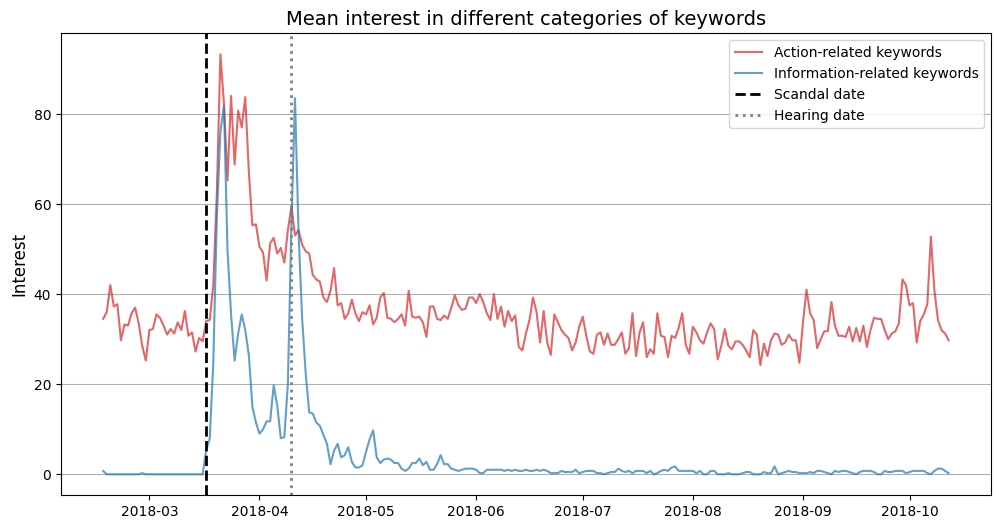

In [52]:
fig, ax = plt.subplots()
fig.set_size_inches(12,6)

ax.plot(action_df["interest"], color= "tab:red", alpha = 0.7, label = "Action-related keywords")
ax.plot(information_df["interest"], color = "tab:blue", alpha = 0.7, label = "Information-related keywords")
ax.grid(True, axis="y")


plt.axvline(event_date, linewidth = 2, color = "black", linestyle = "--", label = "Scandal date")
plt.axvline(hearing_date, linewidth = 2, color = "grey", linestyle = ":", label = "Hearing date")
plt.title("Mean interest in different categories of keywords", fontsize=14)
plt.ylabel("Interest", fontsize = 12)
plt.legend()
plt.show()